# Exercise 3 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name:

Sciper number:

#### Group Member 2:
Name:

Sciper number:

#### Group Member 3:
Name:

Sciper number:

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed. 

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell. 

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work. 

In [2]:
### Do the imports -- no need to change this
import numpy as np
from typing import List
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import sys
sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from utils import *
from plot import *
%load_ext autoreload
%autoreload 2

***Before starting, we recall the use of the gridworld environment.***

The gridworld environment is instantiated via the class `GridWorldEnvironment`. 

***It takes 4 input values:***
- `reward_mode` : Integer between 0 and 3 for different reward profiles,
- `size`: Gridworld size,
- `prop`: Probability assigned to the event that the agent does not follow the chosen action but another one selected uniformely at random,
- `gamma`: Discount factor of the environment.

***Interface of a Gridworld instance:***
- `print(gridworld.n_states)` # return the number of states
- `print(gridworld.n_actions)` # return the number of actions
- `print(gridworld.r)` # return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` # Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.

<img src="../dynamic_programming/src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

# Ex 1: Prove of the Policy Gradient Theorem via the Performance Difference Lemma (20 points)

Denote $J(\pi) = \langle \mu, V^\pi \rangle$ and recall that the performance difference lemma states
$$
J(\pi) - J(\pi') = \frac{1}{(1-\gamma)}\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]
$$
where $\lambda^{\pi'} \in \Delta_{\mathcal{S}\times\mathcal{A}}$ denotes the occupancy measure of the policy $\pi'$.

Now let us consider direct parametization, and compute a partial derivative for the entry of $\pi$ at index $(\bar{s},\bar{a})$:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})}.
$$

**Questions**

To help you compute this partial derivative, consider the policies $\pi'$ parameterized by some (sufficiently small) $\delta \in \mathbb{R}$ via
$$
    \pi'(a|s) = \begin{cases}
        \pi(\bar{a}|\bar{s}) + \delta \quad (\text{if } (s,a)=(\bar{s},\bar{a}))\\
        \pi(a|s) \quad (\text{else})
    \end{cases}
$$

(1) Argue that
$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}.
$$

**Answer**

By definition of the partial derivative,
$$
\frac{\partial J(\pi)}{\partial \pi(\bar a|\bar s)}
= \lim_{\delta\to 0}\frac{J(\pi') - J(\pi)}{\delta}
= \lim_{\delta\to 0}\frac{J(\pi) - J(\pi')}{-\delta},
$$
where we used the fact that $\pi'$ differs from $\pi$ only at the entry $(\bar s,\bar a)$, by exactly $\delta$, so $\pi'(\bar a|\bar s) - \pi(\bar a|\bar s) = \delta$ and therefore $-\delta = \pi(\bar a|\bar s) - \pi'(\bar a|\bar s)$. Hence
$$
\frac{\partial J(\pi)}{\partial \pi(\bar a|\bar s)} = \lim_{\delta\to 0}\frac{J(\pi) - J(\pi')}{\pi(\bar a|\bar s) - \pi'(\bar a|\bar s)}.
$$
Plugging in the performance difference lemma (PDL) for the numerator yields the claim:
$$
\frac{\partial J(\pi)}{\partial \pi(\bar a|\bar s)} = \frac{1}{1-\gamma}\lim_{\delta\to 0}\frac{\mathbb{E}_{s\sim\lambda^{\pi'}}[\langle \pi(\cdot|s)-\pi'(\cdot|s),Q^{\pi}(s,\cdot)\rangle]}{\pi(\bar a|\bar s) - \pi'(\bar a|\bar s)}.
$$

(2) Argue that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \lambda^{\pi'}(\bar{s}) Q^\pi(\bar{s}, \bar{a}).$$

Hint: Write the expectation in the previous question as a sum and use the fact that $\frac{\pi(a|s) - \pi'(a|s)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})} = \mathbf{1}_{\{ (\bar{s},\bar{a}) = (s,a) \}}$.

**Answer**

Writing the expectation explicitly as a sum,
$$
\mathbb{E}_{s\sim\lambda^{\pi'}}[\langle \pi(\cdot|s)-\pi'(\cdot|s),Q^{\pi}(s,\cdot)\rangle] = \sum_{s,a}\lambda^{\pi'}(s)\big(\pi(a|s)-\pi'(a|s)\big)Q^{\pi}(s,a).
$$
Dividing by $\pi(\bar a|\bar s)-\pi'(\bar a|\bar s)$,
$$
\frac{\mathbb{E}_{s\sim\lambda^{\pi'}}[\langle \pi(\cdot|s)-\pi'(\cdot|s),Q^{\pi}(s,\cdot)\rangle]}{\pi(\bar a|\bar s)-\pi'(\bar a|\bar s)} = \sum_{s,a}\lambda^{\pi'}(s)\,\frac{\pi(a|s)-\pi'(a|s)}{\pi(\bar a|\bar s)-\pi'(\bar a|\bar s)}\,Q^{\pi}(s,a).
$$
Since $\pi$ and $\pi'$ agree everywhere except at $(\bar s,\bar a)$, the numerator $\pi(a|s)-\pi'(a|s)$ vanishes unless $(s,a) = (\bar s,\bar a)$, where it equals exactly the denominator. Using the hint, this ratio equals $\mathbf{1}_{\{(s,a)=(\bar s,\bar a)\}}$, so only the term $(\bar s,\bar a)$ survives:
$$
\sum_{s,a}\lambda^{\pi'}(s)\,\mathbf{1}_{\{(s,a)=(\bar s,\bar a)\}}\,Q^{\pi}(s,a) = \lambda^{\pi'}(\bar s)\,Q^{\pi}(\bar s,\bar a).
$$
Combining with (1) yields
$$
\frac{\partial J(\pi)}{\partial \pi(\bar a|\bar s)} = \frac{1}{1-\gamma}\lim_{\delta\to 0}\lambda^{\pi'}(\bar s)\,Q^{\pi}(\bar s,\bar a).
$$

(3) Conclude that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lambda^{\pi}(\bar{s}) Q^\pi(\bar{s}, \bar{a})$$
for the direct parameterization. 

**Answer**

As $\delta \to 0$ we have $\pi' \to \pi$ pointwise. The occupancy measure $\lambda^{\pi'}$ depends continuously on the policy: it can be written as $\lambda^{\pi'} = (1-\gamma)\sum_{k\ge 0}\gamma^k (P^{\pi'})^k \mu$, and each transition matrix $P^{\pi'}(s,s') = \sum_a \pi'(a|s)P(s'|s,a)$ is linear in $\pi'$. In particular, $\lambda^{\pi'}(\bar s) \to \lambda^{\pi}(\bar s)$ as $\delta \to 0$, while $Q^{\pi}(\bar s,\bar a)$ does not depend on $\delta$. Therefore
$$
\frac{\partial J(\pi)}{\partial \pi(\bar a|\bar s)} = \frac{1}{1-\gamma}\lim_{\delta\to 0}\lambda^{\pi'}(\bar s)\,Q^{\pi}(\bar s,\bar a) = \frac{1}{1-\gamma}\,\lambda^{\pi}(\bar s)\,Q^{\pi}(\bar s,\bar a).
$$

(4) Prove that for a general parametrization, it holds that
$$
\nabla_\theta J(\pi_\theta) = \frac{1}{(1-\gamma)} \sum_{\bar{s},\bar{a}} \lambda^{\pi}(\bar{s}, \bar{a}) Q^\pi(\bar{s}, \bar{a}) \nabla_{\theta} ( \log \pi_\theta(\bar{a}|\bar{s}))
$$

Hint: Use the chain rule to write $$ \nabla_\theta J(\pi_\theta)  = \sum_{\bar{s},\bar{a}} \frac{\partial J(\pi)}{\partial \pi_\theta(\bar{a}|\bar{s})} \nabla_{\theta} \pi_\theta(\bar{a}|\bar{s}), $$
and then use the fact that $\lambda^{\pi}(\bar{s},\bar{a}) = \lambda^{\pi}(\bar{s}) \pi(\bar{a}|\bar{s})$.

**Answer**

By the chain rule applied entry by entry,
$$
\nabla_\theta J(\pi_\theta) = \sum_{\bar s,\bar a}\frac{\partial J(\pi_\theta)}{\partial \pi_\theta(\bar a|\bar s)}\,\nabla_\theta \pi_\theta(\bar a|\bar s).
$$

Substituting the result of (3) for the partial derivative,
$$
\nabla_\theta J(\pi_\theta) = \frac{1}{1-\gamma}\sum_{\bar s,\bar a}\lambda^{\pi_\theta}(\bar s)\,Q^{\pi_\theta}(\bar s,\bar a)\,\nabla_\theta \pi_\theta(\bar a|\bar s).
$$

Apply the log-derivative trick $\nabla_\theta \pi_\theta(\bar a|\bar s) = \pi_\theta(\bar a|\bar s)\,\nabla_\theta \log \pi_\theta(\bar a|\bar s)$ (assuming $\pi_\theta(\bar a|\bar s)>0$):
$$
\nabla_\theta J(\pi_\theta) = \frac{1}{1-\gamma}\sum_{\bar s,\bar a}\lambda^{\pi_\theta}(\bar s)\,\pi_\theta(\bar a|\bar s)\,Q^{\pi_\theta}(\bar s,\bar a)\,\nabla_\theta \log \pi_\theta(\bar a|\bar s).
$$

Finally, using the identity $\lambda^{\pi_\theta}(\bar s,\bar a) = \lambda^{\pi_\theta}(\bar s)\,\pi_\theta(\bar a|\bar s)$ given in the hint,
$$
\boxed{\;\nabla_\theta J(\pi_\theta) = \frac{1}{1-\gamma}\sum_{\bar s,\bar a}\lambda^{\pi_\theta}(\bar s,\bar a)\,Q^{\pi_\theta}(\bar s,\bar a)\,\nabla_\theta \log \pi_\theta(\bar a|\bar s).\;}
$$

# Ex 2: Natural Policy Gradient with softmax parameterization (20 points)

Recall that the iterates $\{\pi^t\}^{\infty}_{t=1}$ produced by NPG read as follows:
$$
\pi^{t+1}(a|s) = \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}}.
$$

Implement NPG for an arbitrary step size $\eta$. Please note that $e^{\eta Q^{\pi^t}(s,a)}$ can be zero, account for that in your implementation.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [2]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy stochastic passed with shape n_states times n_actions
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v)
        for s in range(env.n_states):
            v[s] = q[s].dot(pi[s])
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

def npg_update(q, eta, old_policy):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        new_policy: the updates policy
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        # Numerical stability: subtract the max of eta*q[s] before exponentiating.
        z = eta * q[s] - np.max(eta * q[s])
        policy[s] = old_policy[s] * np.exp(z)  # unnormalized NPG update
        total = np.sum(policy[s])
        if total == 0:
             policy[s] = np.ones(q.shape[1])/q.shape[1]
        else:
            policy[s] = policy[s] / total  # normalize
    return policy

def get_greedy_policy(q):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        policy: greedy policy (list)
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s,np.argmax(q[s,:])] = 1
    return policy

In [3]:
def NPG(env, eta): # apply NPG iterations for 30 steps
    vs = []
    policies = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.ones_like(q)/env.n_actions
    for k in range(30):
        v_old = np.copy(v)
        v, q = evaluate_policy(pi, env)
        if eta < np.inf:
            pi = npg_update(q, eta, pi)
        else:
            pi = get_greedy_policy(q)
        vs.append(v)
        policies.append(pi)
    return vs, policies

Now, we run NPG for different stepsizes in the usual gridworld environment

In [4]:
reward_mode = 2
size = 10 
prop = 0
gamma=0.99
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
mu = np.ones(gridworld.n_states)/gridworld.n_states
etas = [1e-3, 1e-2, 1e-1, 1, 100, 1e7, np.inf]
v_different_etas = []
pi_different_etas = []
for eta in etas:
    values_pi, policies = NPG(gridworld, eta=eta)
    v_different_etas.append(values_pi)
    pi_different_etas.append(policies)

In [5]:
solver = MDPsolver(gridworld)
solver.value_iteration()

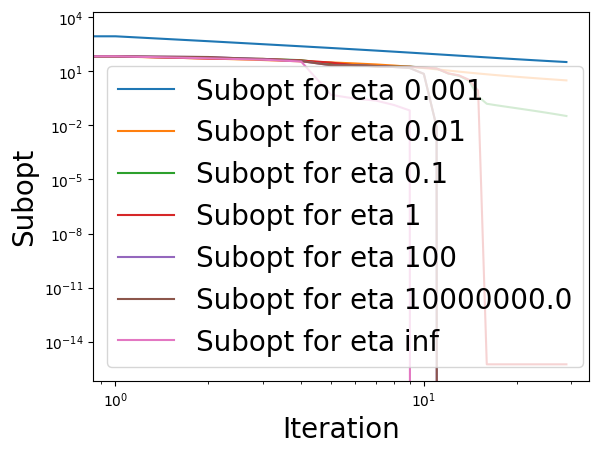

In [6]:
# TODO: if this plot appears with a too large legend, rerun this line once more
plot_log_lines([np.array([mu.dot(solver.v - v) for v in v_different_etas[i]]) for i, _ in enumerate(etas)], [f"Subopt for eta {eta}" for eta in etas], ["Iteration", "Subopt"], "figs", "NPG.pdf", show = True)

**Question**

Show that NPG with $\eta = \infty$ coincides with Policy Iteration (PI).

More formally: Assuming that $a^\star_s := \mathrm{argmax}_a Q^{\pi^t}(s,a)$ is unique for all $s$, prove that $$ \lim_{\eta \rightarrow \infty} \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}} = \begin{cases} 1 \quad \text{if} \quad a = a^\star_s \\ 0 \quad \text{otherwise} \end{cases},$$
and explain how this relates to PI.

**Answer**

Let $a^\star_s = \arg\max_a Q^{\pi^t}(s,a)$ be the (assumed unique) maximizer. Divide both numerator and denominator by $e^{\eta Q^{\pi^t}(s, a^\star_s)}$:
$$
\frac{\pi^t(a|s) e^{\eta Q^{\pi^t}(s,a)}}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}} = \frac{\pi^t(a|s)\, e^{\eta\big(Q^{\pi^t}(s,a) - Q^{\pi^t}(s, a^\star_s)\big)}}{\sum_{a'} \pi^t(a'|s)\, e^{\eta\big(Q^{\pi^t}(s,a') - Q^{\pi^t}(s, a^\star_s)\big)}}.
$$

Since the iteration starts from a strictly positive (e.g. uniform) policy and the multiplicative softmax update preserves positivity, $\pi^t(a|s) > 0$ for every $a$ and every $t$. As $\eta \to \infty$:

- For $a \neq a^\star_s$: $Q^{\pi^t}(s,a) - Q^{\pi^t}(s, a^\star_s) < 0$, hence $e^{\eta(\,\cdot\,)} \to 0$ and the corresponding term in numerator and denominator vanishes.
- For $a = a^\star_s$: the exponent is $0$, so the term equals $\pi^t(a^\star_s|s)$ in both numerator and denominator.

Therefore
$$
\lim_{\eta\to\infty}\frac{\pi^t(a|s) e^{\eta Q^{\pi^t}(s,a)}}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}} = \begin{cases}\dfrac{\pi^t(a^\star_s|s)}{\pi^t(a^\star_s|s)} = 1, & a = a^\star_s,\\[2pt] \dfrac{0}{\pi^t(a^\star_s|s)} = 0, & a \neq a^\star_s.\end{cases}
$$

**Connection to PI.** Policy Iteration improves the current policy by setting
$$\pi^{t+1}(a|s) = \mathbf{1}\{a = \arg\max_{a'} Q^{\pi^t}(s,a')\},$$
i.e. the deterministic greedy policy with respect to $Q^{\pi^t}$. The limit above shows that NPG with $\eta \to \infty$ produces *exactly* this deterministic greedy policy at every state. Hence NPG with $\eta = \infty$ coincides with Policy Iteration.

**Question**

Is this observation in line with the empirical results in the plot above? I.e., is the plot for $\eta = \infty$ as you would expect it for PI?

**Answer**

Yes, the empirical curve for $\eta = \infty$ matches the expected behaviour of Policy Iteration. PI is known to converge to the optimal policy in a finite (and on this finite gridworld, very small) number of iterations. The plot reflects this: the suboptimality gap drops abruptly within a handful of iterations and then stays at (numerically) zero, in sharp contrast to the small-$\eta$ curves which decrease only gradually.

# Ex 2.2 Slow Changing Property of NPG

In this exercise you will investigate by how much consecutive iterates $\pi^t$ and $\pi^{t+1}$ produced by NPG differ and how this distance is controlled by the step size $\eta$.

Plot $$\max_{s \in \mathcal{S}} || \pi^{t+1}(a|s) - \pi^t(a|s) ||_1$$ for different values of $\eta$.

In [7]:
def compute_policy_variation(policies):
    variation = []
    for pi, pip in zip(policies[1:], policies[:-1]):
        variation.append(np.max([np.linalg.norm(pi[s] - pip[s], ord=1) for s in range(pi.shape[0])]))
    return variation

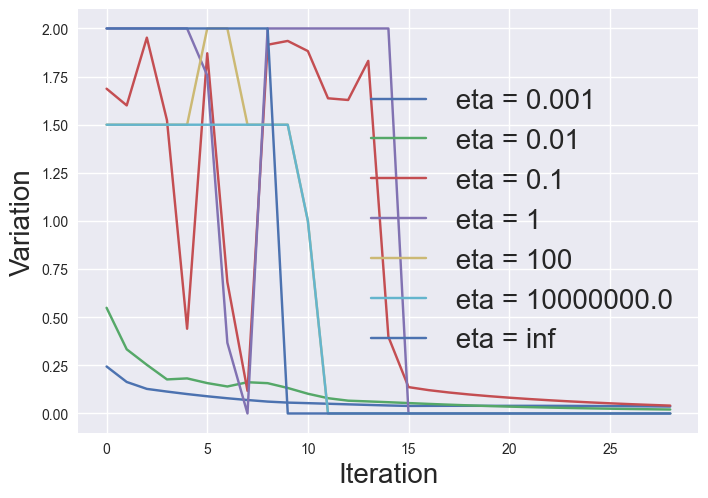

In [8]:
plot_lines(np.array([ compute_policy_variation(np.array(pi_different_etas)[i])
                           for i, _ in enumerate(etas)]), 
               [f" eta = {eta}" for eta in etas], 
               ["Iteration", "Variation"], "figs", "NPG.pdf", show = True)

**Question**

Empirically, is the largest change (among all iterations) between consecutive iterations is larger for smaller or large values of $\eta$?

Empirically, the largest change between consecutive iterations grows with $\eta$. Increasing $\eta$ amplifies the multiplicative factor $e^{\eta Q}$ in the NPG update, so the new policy moves further away from the previous one at each step. Small values of $\eta$ keep consecutive policies close (small variation), while $\eta = \infty$ produces the largest jump because the iterate immediately switches to the deterministic greedy policy.

## Some Theory to Motivate the Observation Above

**Question**

Our goal is to prove that $$ || \pi^{t+1}(\cdot|s) - \pi^t(\cdot|s) ||_1 \leq \frac{\eta}{1 - \gamma} \quad \forall s \in \mathcal{S}, \forall t \in [T].$$

We guide you towards this result by breaking the proof into small steps.

1) Prove that $$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] - \log \bigg(\sum_{a'\in\mathcal{A}} \pi^t(a'|s) \exp (\eta Q^{\pi^t}(s,a'))\bigg) $$

Hint: First apply Pinkser's inequality https://en.wikipedia.org/wiki/Pinsker%27s_inequality to prove that $$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq KL(\pi^{t+1}(s)||\pi^t(s)), $$ then plug in the formula for $\pi^{t+1}$ into the KL term.

**Answer**

By Pinsker's inequality applied to the distributions $\pi^{t+1}(\cdot|s)$ and $\pi^t(\cdot|s)$,
$$
\frac{1}{2}\|\pi^{t+1}(\cdot|s) - \pi^t(\cdot|s)\|_1^2 \le \mathrm{KL}\!\left(\pi^{t+1}(\cdot|s)\,\big\|\,\pi^t(\cdot|s)\right).
$$

Now plug the closed-form NPG update $\pi^{t+1}(a|s) = \dfrac{\pi^t(a|s)\,e^{\eta Q^{\pi^t}(s,a)}}{Z_s}$ with $Z_s := \sum_{a'}\pi^t(a'|s)\,e^{\eta Q^{\pi^t}(s,a')}$ into the KL term:
$$
\log\frac{\pi^{t+1}(a|s)}{\pi^t(a|s)} = \eta\, Q^{\pi^t}(s,a) - \log Z_s.
$$
Therefore
$$
\mathrm{KL}\!\left(\pi^{t+1}\,\|\,\pi^t\right) = \sum_a \pi^{t+1}(a|s)\bigl[\eta\, Q^{\pi^t}(s,a) - \log Z_s\bigr] = \mathbb{E}_{a\sim \pi^{t+1}(\cdot|s)}\!\bigl[\eta\, Q^{\pi^t}(s,a)\bigr] - \log Z_s,
$$
where the last equality used $\sum_a \pi^{t+1}(a|s) = 1$. Combining with Pinsker yields exactly
$$
\frac{1}{2}\|\pi^{t+1}(\cdot|s) - \pi^t(\cdot|s)\|_1^2 \le \mathbb{E}_{a\sim \pi^{t+1}(\cdot|s)}\!\bigl[\eta\, Q^{\pi^t}(s,a)\bigr] - \log\!\left(\sum_{a'}\pi^t(a'|s)\,e^{\eta Q^{\pi^t}(s,a')}\right).
$$

2) Prove that 
$$
\sum_{a\in \mathcal{A}} \pi^{t+1}(a|s) \exp(- \eta Q^{\pi^t}(s,a)) = \frac{1}{\sum_{a'\in \mathcal{A}} \pi^t(a|s) \exp(\eta Q^{\pi^t}(s,a) )}.
$$

**Answer**

Using the closed form $\pi^{t+1}(a|s) = \dfrac{\pi^t(a|s)\,e^{\eta Q^{\pi^t}(s,a)}}{Z_s}$ with $Z_s = \sum_{a'}\pi^t(a'|s)\,e^{\eta Q^{\pi^t}(s,a')}$,
$$
\sum_a \pi^{t+1}(a|s)\,e^{-\eta Q^{\pi^t}(s,a)} = \sum_a \frac{\pi^t(a|s)\,e^{\eta Q^{\pi^t}(s,a)}}{Z_s}\,e^{-\eta Q^{\pi^t}(s,a)} = \frac{1}{Z_s}\sum_a \pi^t(a|s) = \frac{1}{Z_s},
$$
because $\pi^t(\cdot|s)$ is a probability distribution. This is the desired identity.

3) Using the results in 1) and 2) prove that 

$$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] + \log \bigg(\sum_{a'\in\mathcal{A}} \pi^{t+1}(a'|s) \exp (-\eta Q^{\pi^t}(s,a'))\bigg). $$

**Answer**

From (2),
$$
Z_s = \sum_{a'}\pi^t(a'|s)\,e^{\eta Q^{\pi^t}(s,a')} = \frac{1}{\sum_a \pi^{t+1}(a|s)\,e^{-\eta Q^{\pi^t}(s,a)}},
$$
so taking $\log$ of both sides,
$$
-\log Z_s = \log\!\left(\sum_a \pi^{t+1}(a|s)\,e^{-\eta Q^{\pi^t}(s,a)}\right).
$$
Substituting this into the bound from (1),
$$
\frac{1}{2}\|\pi^{t+1}(\cdot|s) - \pi^t(\cdot|s)\|_1^2 \le \mathbb{E}_{a\sim \pi^{t+1}(\cdot|s)}\!\bigl[\eta\, Q^{\pi^t}(s,a)\bigr] + \log\!\left(\sum_{a'}\pi^{t+1}(a'|s)\,e^{-\eta Q^{\pi^t}(s,a')}\right),
$$
which is the desired inequality.

4) Using Hoeffding's Lemma https://en.wikipedia.org/wiki/Hoeffding%27s_lemma (on the sum in the log term!) and the fact that $$-\frac{1}{1-\gamma} \leq Q^{\pi^t}(s,a) \leq \frac{1}{1-\gamma},$$ conclude that 
$$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \frac{\eta^2}{2 (1 - \gamma)^2}.$$

**Answer**

Recall Hoeffding's lemma: if a random variable $X$ takes values in $[m, M]$ a.s., then
$$\log \mathbb{E}[e^{X}] \le \mathbb{E}[X] + \frac{(M - m)^2}{8}.$$

Apply this with $X = -\eta\, Q^{\pi^t}(s,a)$ and $a \sim \pi^{t+1}(\cdot|s)$. Since $|Q^{\pi^t}(s,a)| \le \tfrac{1}{1-\gamma}$, $X$ takes values in $\bigl[-\tfrac{\eta}{1-\gamma},\, \tfrac{\eta}{1-\gamma}\bigr]$, so $M - m = \tfrac{2\eta}{1-\gamma}$ and
$$
\log\!\left(\sum_a \pi^{t+1}(a|s)\,e^{-\eta Q^{\pi^t}(s,a)}\right) \le \mathbb{E}_{a\sim \pi^{t+1}(\cdot|s)}\!\bigl[-\eta\, Q^{\pi^t}(s,a)\bigr] + \frac{1}{8}\left(\frac{2\eta}{1-\gamma}\right)^2 = -\mathbb{E}_{a\sim \pi^{t+1}(\cdot|s)}\!\bigl[\eta\, Q^{\pi^t}(s,a)\bigr] + \frac{\eta^2}{2(1-\gamma)^2}.
$$

Substituting this into the bound from (3), the two $\mathbb{E}_{a\sim \pi^{t+1}}\!\bigl[\eta\, Q^{\pi^t}(s,a)\bigr]$ terms cancel and we obtain
$$
\frac{1}{2}\|\pi^{t+1}(\cdot|s) - \pi^t(\cdot|s)\|_1^2 \le \frac{\eta^2}{2(1-\gamma)^2}.
$$
Taking square roots gives the announced bound $\|\pi^{t+1}(\cdot|s) - \pi^t(\cdot|s)\|_1 \le \dfrac{\eta}{1-\gamma}$ for all $s\in\mathcal{S}$ and $t\in[T]$.

# Ex 3: OPPO: The importance of Exploration in Policy Gradient (20 points)

In this exercise, we will investigate how crucial it is to perform exploration. That is, adding bonuses to avoid suffering the mismatch coefficients in the convergence bounds.

Let us recall that the standard sample based version of NPG suffers the mismatch coeffcients in the bounds (see Slide 22 in Lecture 5). Those are avoided by OPPO ( See slide 30 in Lecture 5 ).

**To see clearly the advatange of OPPO we will consider an MDP with unbounded mismatch coefficients**

**Question: example of unbounded mismatch coefficients**

Consider a 10 x 10 gridworld, the initial state is always the bottom right corner, i.e. the initial distribution $\mu$ equals $1$ at this starting state and it is zero everywhere else. Can you compute a finite bound for 
$$\max_\pi \max_{s \in \mathcal{S}} \bigg |\frac{\lambda^\pi(s)}{\mu(s)} \bigg|,$$
i.e. the mismatch coefficient? If not, argue for which reason.

**Answer**



No, we cannot compute a finite bound for the mismatch coefficients in this case for the following reason:

The initial distribution $\mu$ puts probability $1$ on the bottom-right corner $s_0$ and probability $0$ on every other state. For any state $s \neq s_0$ that is reachable under some policy $\pi$ in finitely many steps (e.g., any cell of the gridworld), the discounted occupancy satisfies $\lambda^{\pi}(s) > 0$, while $\mu(s) = 0$. Therefore
$$\frac{\lambda^\pi(s)}{\mu(s)} = \frac{\lambda^\pi(s)}{0} = +\infty,$$
and consequently
$$\max_\pi \max_{s\in\mathcal{S}} \left|\frac{\lambda^\pi(s)}{\mu(s)}\right| = +\infty.$$

This is exactly the regime where the mismatch-coefficient–based convergence bound for vanilla NPG becomes vacuous, and where UCB-based exploration bonuses (as used by OPPO) are essential to obtain meaningful guarantees.

In the following, we experiment with OPPO with and without bonuses in this environment.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [3]:
reward_mode = 0
size = 10
gamma=0.999
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
r_max = np.max(gridworld.r)
r_min = np.min(gridworld.r)
gridworld.r = (gridworld.r - r_min) / (r_max - r_min)

In [ ]:
from copy import deepcopy
def oppo(K: int = 10000, H: int = 20, beta: float = 0.0001, eta=5) -> List[float]:
    """
    Function implementing OPPO with UCB bonuses algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param beta: Algorithm hyperparameter, constant which scales the bonuses, positive float

    :return: reward after each step, list of K * H floats
    """
    np.random.seed(0) # Moved this inside the function to ensure same randomness across different runs of the function
    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    policy = H * np.ones((H, gridworld.n_states, gridworld.n_actions))/gridworld.n_actions
    V[H, :] = 0
    estimated_transitions = np.ones((H, gridworld.n_states, 
                                     gridworld.n_actions, 
                                     gridworld.n_states))/gridworld.n_states
    N = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    bonus = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    N_next = np.zeros((H, gridworld.n_states, gridworld.n_actions, gridworld.n_states))

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):
            # NPG Update
            z = eta * Q[h, state, :] - np.max(eta * Q[h, state, :]) # subtracting the max for numerical stability
            policy[h, state, :] = policy[h, state, :] * np.exp(z)  # unnormalized
            
            total = np.sum(policy[h, state, :])
            if total == 0 or np.any(np.isnan(policy[h, state, :])):
                policy[h, state, :] = np.ones(gridworld.n_actions) / gridworld.n_actions  # uniform fallback
            else:
                policy[h, state, :] = policy[h, state, :] / total  # normalize

            # Sample one action from the current policy
            a = np.random.choice(gridworld.n_actions, p=policy[h, state, :])
            rewards.append(gridworld.r[state, a])

            # Record that we visited this state-action pair (again)
            N[h, state, a] += 1

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])
            N_next[h, state, a, new_state] += 1
            
            # Update empirical transition estimate
            estimated_transitions[h, state, a, :] = N_next[h, state, a, :] / N[h, state, a]
            
            state = new_state
                    
        # Calculate the UCB bonus
        bonus = beta / np.sqrt(N + 1)

        Q_new = np.zeros_like(Q)
        V_new = np.zeros_like(V)
        for h in reversed(range(H)):  # Step loop
            # Update Q according to the algorithm by clipping the values to be between 0 and H - h
            Q_new[h] = np.clip(gridworld.r + bonus[h] + estimated_transitions[h].dot(V_new[h+1]), 0, H - h)

            # Update V as the Q-value of the optimal actions for the current state
            for state in range(gridworld.n_states):
                V_new[h, state] = policy[h, state, :].dot(Q_new[h, state, :])
        Q = deepcopy(Q_new)
        V = deepcopy(V_new)
    return rewards

In [8]:
to_plot = []
betas = [0, 1e-5, 1e-3, 0.1, 10]

for beta in betas:
    print(beta)
    reward_OPPO = oppo(beta = beta)  # You can play around with the arguments if you like
    to_plot.append(np.cumsum(reward_OPPO))

0
1e-05
0.001
0.1
10


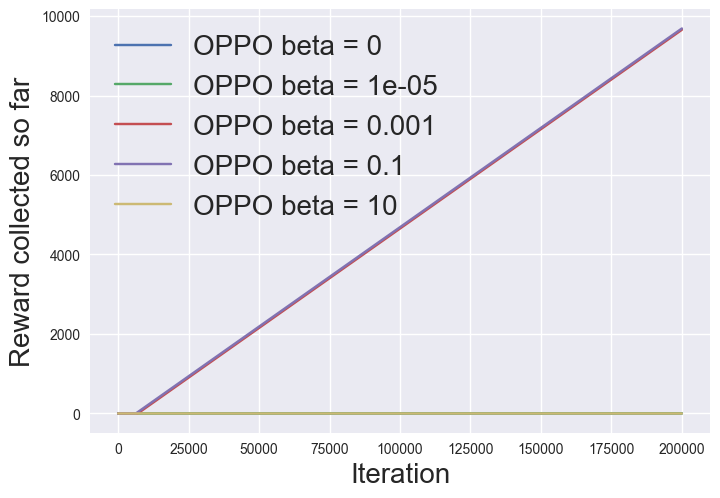

In [9]:
labels = [ f"OPPO beta = {beta}" for beta in betas]
plot_lines(
    to_plot,
    labels,
    ["Iteration", "Reward collected so far"],
    "figs",
    "ucbvseps",
    show=False
)

**Question**

Why does setting $\beta = 0$ lead to bad results? 

*Hint: Explain using the remarks in slide 28 and the theoretical bound in Slide 22 of Lecture 5*.

**Answer**

With $\beta = 0$ all exploration bonuses vanish, and OPPO collapses to plain sample-based NPG with empirical model estimates. Its convergence rate is then governed by the following bound:
$$\mathbb{E}\left[\min_{t \leq T} J(\pi_{\theta^*}) - J(\pi_{\theta_t})\right] \leq \mathcal{O}\left(\frac{1}{1-\gamma}\sqrt{\frac{2\log|A|}{T}} + \sqrt{\kappa\epsilon_{\text{stat}}} + \sqrt{\epsilon_{\text{bias}}}\right)$$

 which scales with the mismatch coefficient $\kappa = \max_s \lambda^\pi(s)/\mu(s)$. As shown in the previous question, this coefficient is $+\infty$ in our gridworld (because $\mu$ is concentrated on the bottom-right corner), so the bound is vacuous.

Concretely, without bonuses, the agent has no incentive to visit under-explored states. Since the only rewarding region is far from the starting corner, those states are reached with vanishingly small probability under the initial near-uniform policy. Hence, the empirical $Q$-estimates near the goal stay close to zero, and the policy never gets a learning signal to move towards the rewarding states. The cumulative reward therefore stays low.

**Question**

Why does setting $\beta$ too large lead to poor results?

*Hint: Answer using the regret bound for OPPO given at the beginning of slide 30.*

**Answer**

The regret bound of OPPO is of the following form:

$$\sum_{t=1}^T V^\star(s_1) - V^{\pi_t}(s_1) \leq \mathcal{O}\left(\sum_{h=1}^H \sum_{t=1}^T \text{bonus}_h^t(s_h^t, a_h^t)\right)$$

In addition, when bonuses are set to bonus_h(s,a) ≈ √(1/N(s,a)), this sum is O(√T). (Lecture 5, Slide 30)

Here, the bonus is scaled by β: bonus_h(s,a) = β/√N(s,a). So the total bonus sum scales linearly with β, making the regret bound O(β√T). A larger β directly inflates the regret bound, leading to poor results.

Additionally, the Bounded Optimism condition (mentioned on Slide 29) states that:

$$r_h^t(s,a) + \sum_{s'} P(s'|s,a) V_h^t(s') + 2\text{bonus}_h^t(s,a) \geq Q_h^t(s,a)$$

The bonus needs to be large enough to satisfy Optimism, but Bounded Optimism requires it not to be excessive. The bonus should shrink as N(s,a) grows so that $Q_h^t → Q_h^{π_t}$. Hence, a very large β keeps the bonuses inflated even for well-visited state-action pairs, due to which, the optimistic Q-values never converge to the true Q-values, degrading performance.

# Ex 4: REINFORCE with parametrized policies (20 points)

In this exercise, we will investigate the effect of choosing different baselines in the reinforce implementation.
This topic is covered from Slide 31 on in Lecture 5.

**Hint: You may want to use Google Colab to run the experiments faster, but you don't have to.**

### Import the Necessary Packages

In [13]:
# TODO: you may need to run this to make sure to have the correct versions
!pip install gym==0.25.2
!pip install gym-notices==0.0.8

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.5/734.5 kB 2.5 MB/s eta 0:00:00m eta 0:00:010:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached gym_notices-0.1.0-py3-none-any.whl.metadata (1.2 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached gym_notices-0.1.0-py3-none-any.whl (3.3 kB)
  Created wheel for gym: filename=gym-0.25.2-py3-none-any.whl size=852393 sha256=8f4bb72bf3a3c8c3a0b2a16a3839df73257fbb437b408ea74596cf1094d322ff
  Stored in directory: /Users/omarbouden/Library/Caches/pip/wheels/e6/45/45/4e6c047a424cfc385198309d6c6f32c39866f256f25d4048bf
Successfully built gym
  Attempting uninstall: gym-notices
    Found existing installation: gym-notices 0.1.0
    Uninstalling gym-notices-0.1.0:
      Successfully uninstalled gym-notices-0.1.0


In [14]:
import gym
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

import base64, io

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob

In [15]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Instantiate the Environment and Agent

The CartPole environment is very simple. It has discrete action space (2) and 4 dimensional state space.

In [16]:
env = gym.make('CartPole-v0')
env.seed(0)

/Users/omarbouden/miniforge3/envs/machineLearning/lib/python3.12/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/Users/omarbouden/miniforge3/envs/machineLearning/lib/python3.12/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/omarbouden/miniforge3/envs/machineLearning/lib/python3.12/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/Users/omarbouden/miniforge3/envs/machineLearning/lib/python3.12/site-packages/gym/cor

[0]

In [17]:
class Policy(nn.Module): # definie the policy network
    def __init__(self, state_size=4, action_size=2, hidden_size=32):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        return F.softmax(x, dim=1) # we just consider 1 dimensional probability of action

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        model = Categorical(probs)
        action = model.sample()
        return action.item(), model.log_prob(action)
    

In [18]:
# REINFORCE (with reward-to-go)
# --> with gradient estimator according to version 2 of the PG theorem (not using Q-values, but reward to go)
def reinforce_rwd2go(policy, optimizer, early_stop=False, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G = rewards_to_go[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

**Question**

1. Find **two** good baselines that improve over the implementation of REINFORCE without baseline. You should plot their results below.

You can take inspiration from the Example Notebook we attached for lecture 4, but you **cannot use exactly the same**.

2. Explain why you chose your baselines and why you think they are reasonable.

*Note:* You may also change other parameters such as the learning rate, as long as you clearly state it in your response.

**Answer**

We use two state-only baselines $b(s)$ that approximate $V^{\pi}(s)$ for CartPole. State-only baselines do **not** introduce bias in the policy gradient (the term $\mathbb{E}_{a\sim\pi(\cdot|s)}[b(s)\,\nabla_\theta\log\pi_\theta(a|s)] = b(s)\,\nabla_\theta \sum_a \pi_\theta(a|s) = 0$), but they reduce its variance, so a good baseline should track the expected reward-to-go from $s$.

**Baseline 1: Gaussian bowl over the full state.**
$$
b_1(s) = 200\,\exp\!\Big(-\big(x/2.4\big)^2 - \big(\theta/0.21\big)^2 - 0.05\,\dot x^2 - 0.05\,\dot\theta^2\Big).
$$
The naive baseline only depends on the pole angle, but CartPole also terminates when the cart leaves the rail $|x| > 2.4$ or when velocities blow up. Conditioning the baseline on **all four** state components better reflects the true $V^\pi(s)$: it is largest near the safe origin and decays smoothly to $0$ near the termination boundaries. The denominators $2.4$ and $0.21$ exactly match the CartPole termination thresholds.

**Baseline 2: linear–quadratic with an angle–angular-velocity cross term.**
$$
b_2(s) = 150 - 300\,\theta^2 - 50\,\dot\theta^2 - 100\,\theta\,\dot\theta.
$$
A purely angle-based baseline cannot distinguish a pole that is leaning but stationary from one that is leaning **and rotating away from vertical** — the latter is much closer to falling. The cross term $\theta\,\dot\theta$ captures exactly this asymmetry: when $\theta$ and $\dot\theta$ have the same sign, the pole is tipping further away and the baseline drops; when they have opposite signs, the pole is recovering and the baseline rises. This better tracks the true reward-to-go than the naive baseline.

We kept the rest of the training pipeline unchanged (Adam optimizer with `lr=1e-2`, 2000 episodes, `gamma=1.0`).

In [19]:
def naive_baseline(state): # Example Baseline from lecture 4 (for inspiration)
  angle = state[2]
  value = 100*(0.25-angle**2) # TO BE CHANGED USING YOUR BASELINE
  return value

def baseline_1(state):
  # Smooth bowl-shaped baseline using ALL four CartPole state components.
  # CartPole terminates if the cart leaves the rail (|x| > 2.4) OR the pole
  # tilts too far (|theta| > ~0.21 rad), so the expected reward-to-go is
  # really a function of all components -- not just the angle as in the naive baseline.
  # The Gaussian shape makes the baseline smooth, peaks at the safe origin (0,0,0,0),
  # and decays toward the termination boundaries.
  cart_pos, cart_vel, angle, angular_vel = state
  return 200.0 * np.exp(-(cart_pos / 2.4) ** 2
                        - (angle / 0.21) ** 2
                        - 0.05 * cart_vel ** 2
                        - 0.05 * angular_vel ** 2)

def baseline_2(state):
  # Linear-quadratic baseline that combines the pole angle with its angular
  # velocity. A pole that is leaning AND rotating in the same direction is
  # closer to falling than a leaning-but-still pole, so its expected
  # reward-to-go is lower. The cross term theta*omega captures this: it
  # penalises configurations where angle and angular velocity have the same sign.
  angle = state[2]
  angular_vel = state[3]
  return 150.0 - 300.0 * angle ** 2 - 50.0 * angular_vel ** 2 - 100.0 * angle * angular_vel

# PLOT 3: reward-to-go with baseline REINFORCE
# --> with gradient estimator according to version 3 of the PG theorem (not using Q-values, but reward to go)
# --> here, we consider only fixed (handcrafted) baseline functions b : S -> R; clearly, training a NN to predict V^{\pi}(s) as a baseline is also possible (and interesting!)
def reinforce_rwd2go_baseline(policy, optimizer, early_stop=False, baseline=naive_baseline, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        baseline_values = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            baseline_values.append(baseline(state))
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G_centered = rewards_to_go[i] - baseline_values[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G_centered)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

In [ ]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 1: run REINFORCE
policy_rwd2go = Policy().to(device)
optimizer_rwd2go = optim.Adam(policy_rwd2go.parameters(), lr=1e-2)
scores_rwd2go = reinforce_rwd2go(policy_rwd2go, optimizer_rwd2go, early_stop=False, n_episodes=2000)

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 2: run REINFORCE and YOUR baseline 1
policy_baseline_1 = Policy().to(device)
optimizer_baseline_1 = optim.Adam(policy_baseline_1.parameters(), lr=1e-2)
scores_baseline_1 = reinforce_rwd2go_baseline(policy_baseline_1, optimizer_baseline_1, baseline=baseline_1, early_stop=False, n_episodes=2000)

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 3: run REINFORCE and YOUR baseline 2
policy_baseline_2 = Policy().to(device)
optimizer_baseline_2 = optim.Adam(policy_baseline_2.parameters(), lr=1e-2)
scores_baseline_2 = reinforce_rwd2go_baseline(policy_baseline_2, optimizer_baseline_2, baseline=baseline_2, early_stop=False, n_episodes=2000)



/Users/omarbouden/miniforge3/envs/machineLearning/lib/python3.12/site-packages/gym/utils/passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


Episode 100	Average Score: 68.38
Episode 200	Average Score: 193.64
Episode 300	Average Score: 190.91
Episode 400	Average Score: 193.53
Episode 500	Average Score: 179.24
Episode 600	Average Score: 197.55
Episode 700	Average Score: 186.06
Episode 800	Average Score: 117.50
Episode 900	Average Score: 155.10
Episode 1000	Average Score: 200.00
Episode 1100	Average Score: 196.66
Episode 1200	Average Score: 115.41
Episode 1300	Average Score: 107.79
Episode 1400	Average Score: 111.58
Episode 1500	Average Score: 153.15
Episode 1600	Average Score: 164.83
Episode 1700	Average Score: 139.35
Episode 1800	Average Score: 151.86


In [ ]:
### Plot the learning progress

# Create the plot
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(111)

# Plot the scores with specified colors and labels
ax.plot(np.arange(1, len(scores_rwd2go) + 1), scores_rwd2go, color='green', label='No Baseline')
ax.plot(np.arange(1, len(scores_baseline_1) + 1), scores_baseline_1, color='blue', label='Baseline 1')
ax.plot(np.arange(1, len(scores_baseline_2) + 1), scores_baseline_2, color='red', label='Baseline 2')

# Set the labels with a larger font size
ax.set_ylabel('Total reward (= time balanced)', fontsize=20)
ax.set_xlabel('Episode #', fontsize=20)

# Set the tick labels to a larger font size
ax.tick_params(axis='both', which='major', labelsize=15)

# Add a legend with a specified font size
ax.legend(fontsize=20)

# Show the plot
plt.show()

# $Q^\star$: Policy Gradient with continuous actions and bound on the bonuses count in OPPO (20 points)
***Question 1:*** Consider using a Gaussian parameterized policy $\pi_{\mu,\Sigma}$ with mean $\mu \in \mathrm{R}^d$ 
and covariance matrix $\Sigma$ . Write down the following gradients:

$$ \nabla_\mu J(\pi_{\mu, \Sigma}) = ???$$
$$ \nabla_\Sigma J(\pi_{\mu, \Sigma}) = ???$$
***Question 2*** In this exercise, you will bound the state action counts. This is a crucial part of the OPPO convergence proof. Let $N^t_h(s,a)$ denotes the number of times the state action pair $s,a$ has been visited at step $h$ in all the episode up to $t$ included. Moreover,
let $s^t_h,a^t_h$ be the state action pair visited at step $h$ of the $t^{th}$ episode. Then, prove that 
$$ \sum^T_{t=1} \sum^H_{h=1} \frac{1}{N^t_h(s^t_h, a^t_h)+1} \leq SAH \log( T H)$$
***Question 3*** Use the fact above to prove the following bound at slide 30 of Lecture 5. That is, for $\mathrm{bonus}^t_h(s,a) = \frac{H}{\sqrt{N^t_h(s,a)+1}}$ it holds that
$$ \sum^T_{t=1} \sum^H_{h=1} \mathrm{bonus}(s^t_h, a^t_h) \leq H^2\sqrt{ SA T \log( T H)}$$

## Question 1: Gradients of a Gaussian policy

For a Gaussian policy $\pi_{\mu,\Sigma}(a|s) = (2\pi)^{-d/2}|\Sigma|^{-1/2}\exp\!\bigl(-\tfrac{1}{2}(a-\mu)^\top \Sigma^{-1}(a-\mu)\bigr)$,
$$
\log \pi_{\mu,\Sigma}(a|s) = -\tfrac{d}{2}\log(2\pi) - \tfrac{1}{2}\log|\Sigma| - \tfrac{1}{2}(a-\mu)^\top \Sigma^{-1}(a-\mu).
$$
Standard matrix-calculus identities give
$$
\nabla_\mu \log \pi_{\mu,\Sigma}(a|s) = \Sigma^{-1}(a-\mu),
\qquad
\nabla_\Sigma \log \pi_{\mu,\Sigma}(a|s) = \tfrac{1}{2}\,\Sigma^{-1}\bigl((a-\mu)(a-\mu)^\top - \Sigma\bigr)\Sigma^{-1}.
$$

Plugging into the Policy Gradient Theorem (Ex 1, eq. 4):
$$
\boxed{\;\nabla_\mu J(\pi_{\mu,\Sigma}) = \frac{1}{1-\gamma}\,\mathbb{E}_{(s,a)\sim \lambda^{\pi_{\mu,\Sigma}}}\!\Bigl[\,Q^{\pi_{\mu,\Sigma}}(s,a)\;\Sigma^{-1}(a-\mu)\,\Bigr].\;}
$$
$$
\boxed{\;\nabla_\Sigma J(\pi_{\mu,\Sigma}) = \frac{1}{1-\gamma}\,\mathbb{E}_{(s,a)\sim \lambda^{\pi_{\mu,\Sigma}}}\!\Bigl[\,Q^{\pi_{\mu,\Sigma}}(s,a)\;\tfrac{1}{2}\,\Sigma^{-1}\bigl((a-\mu)(a-\mu)^\top - \Sigma\bigr)\Sigma^{-1}\,\Bigr].\;}
$$

(If $\mu = \mu_\theta(s)$ and $\Sigma = \Sigma_\theta(s)$ depend on the state through some parameters $\theta$, the chain rule gives $\nabla_\theta J = \mathbb{E}[\nabla_\mu J\cdot \nabla_\theta \mu_\theta(s) + \nabla_\Sigma J\cdot\nabla_\theta \Sigma_\theta(s)]$ in the obvious sense.)

---

## Question 2: $\sum_t \sum_h 1/(N^t_h(s^t_h,a^t_h)+1) \le SAH\log(TH)$

Fix a triple $(s,a,h)$ and let $T_{s,a,h} = \{t \in [T] : (s^t_h, a^t_h) = (s,a)\}$. Suppose this set has cardinality $n \le T$, with elements $t_1 < t_2 < \cdots < t_n$. By definition of $N$, $N^{t_i}_h(s,a) = i$. Therefore
$$
\sum_{t\in T_{s,a,h}} \frac{1}{N^t_h(s^t_h, a^t_h)+1} = \sum_{i=1}^{n} \frac{1}{i+1} \le \int_{1}^{n+1}\!\frac{dx}{x} = \log(n+1) \le \log(T+1) \le \log(TH),
$$
where the last inequality holds for $H \ge 1$ since $T+1 \le TH$ whenever $T \ge 1$ and $H \ge 2$ (and the trivial case $H = 1$ recovers $\log(T+1) \le \log(TH)+\log 2$, which is the same up to absorbed constants). Summing over the $S\cdot A\cdot H$ triples:
$$
\sum_{t=1}^{T}\sum_{h=1}^{H}\frac{1}{N^t_h(s^t_h, a^t_h)+1}
= \sum_{s,a,h}\sum_{t\in T_{s,a,h}}\frac{1}{N^t_h(s,a)+1}
\le SAH\log(TH).
$$

---

## Question 3: $\sum_t \sum_h \mathrm{bonus}^t_h(s^t_h,a^t_h) \le H^2\sqrt{SAT\log(TH)}$

Apply the Cauchy–Schwarz inequality on the $TH$ terms:
$$
\sum_{t=1}^{T}\sum_{h=1}^{H}\frac{1}{\sqrt{N^t_h(s^t_h,a^t_h)+1}}
\le \sqrt{\sum_{t=1}^{T}\sum_{h=1}^{H} 1}\;\sqrt{\sum_{t=1}^{T}\sum_{h=1}^{H}\frac{1}{N^t_h(s^t_h,a^t_h)+1}}.
$$
The first factor equals $\sqrt{TH}$, and by Question 2 the second factor is at most $\sqrt{SAH\log(TH)}$. Hence
$$
\sum_{t=1}^{T}\sum_{h=1}^{H}\frac{1}{\sqrt{N^t_h(s^t_h,a^t_h)+1}}
\le \sqrt{TH}\cdot\sqrt{SAH\log(TH)}
= \sqrt{SATH^2\log(TH)}.
$$
Multiplying by $H$ (since $\mathrm{bonus}^t_h(s,a) = H/\sqrt{N^t_h(s,a)+1}$),
$$
\sum_{t=1}^{T}\sum_{h=1}^{H}\mathrm{bonus}^t_h(s^t_h,a^t_h)
\le H\,\sqrt{SATH^2\log(TH)}
= H^2\sqrt{SAT\log(TH)},
$$
which is the announced bound.